# VIX–VXN Spread as a Risk Regime Signal

This notebook investigates whether the relative spread between VXN and VIX contains information about market conditions.

The focus is not on predicting direction, but on characterizing when taking risk is more or less favorable.

The analysis is intentionally kept simple:

- core variable: spread_rel  
- event definition: rolling 252-day p10 threshold (shifted)  
- dependence control: 21-day cooldown  
- dimensions analyzed: compression dynamics and local positioning  

The objective is to evaluate whether the spread can be used as a risk regime filter.

In [19]:
!pip install yfinance -q

import pandas as pd
import numpy as np
import yfinance as yf

## 1. Data download and preprocessing

We use three daily time series from Yahoo Finance:

- S&P 500 (`^GSPC`)
- VIX (`^VIX`)
- VXN (`^VXN`)

This section constructs a clean, aligned daily dataset using closing prices only.

In [20]:
tickers = {
    "SPX": "^GSPC",
    "VIX": "^VIX",
    "VXN": "^VXN",
}

start_date = "2006-01-01"
end_date = "2026-03-01"


def download_close_series(ticker: str, col_name: str) -> pd.DataFrame:
    """
    Download daily price data from Yahoo Finance and return a clean Close series.

    - Uses adjusted prices
    - Handles MultiIndex columns if present
    - Returns a time-indexed DataFrame with a single column
    """
    df = yf.download(
        ticker,
        start=start_date,
        end=end_date,
        progress=False,
        auto_adjust=True
    )

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    df = df[["Close"]].copy()
    df = df.rename(columns={"Close": col_name})

    df.index = pd.to_datetime(df.index)
    df = df.sort_index()

    return df


# download series
spx = download_close_series(tickers["SPX"], "SPX")
vix = download_close_series(tickers["VIX"], "VIX")
vxn = download_close_series(tickers["VXN"], "VXN")

# align datasets on common dates
df = spx.join(vix, how="inner").join(vxn, how="inner")
df.columns.name = None

# quick sanity checks
print("Shape:", df.shape)
print("\nNaNs by column:")
print(df.isna().sum())
print("\nDuplicated dates:", df.index.duplicated().sum())
print("Index sorted:", df.index.is_monotonic_increasing)

df.head()

Shape: (5070, 3)

NaNs by column:
SPX    0
VIX    0
VXN    0
dtype: int64

Duplicated dates: 0
Index sorted: True


,SPX,VIX,VXN
Date,,,
2006-01-03,1268.800049,11.14,14.69
2006-01-04,1273.459961,11.37,14.85
2006-01-05,1273.479980,11.31,15.01
2006-01-06,1285.449951,11.00,14.95
2006-01-09,1290.150024,11.13,15.66


## 2. Core variable and event definition

The core variable is the relative spread:

`spread_rel = (VXN - VIX) / VIX`

This normalization makes the spread comparable across different volatility regimes.

An event is defined when the relative spread falls below its rolling 252-day 10th percentile.

To avoid look-ahead bias, the threshold is shifted so that each event is evaluated using only information available at that point in time.

A 21-day cooldown is applied to reduce event clustering.

## 2.1 Core variable construction

In [21]:
df["spread"] = df["VXN"] - df["VIX"]
df["spread_rel"] = (df["VXN"] - df["VIX"]) / df["VIX"]

# rolling 252-day 10th percentile, shifted to avoid look-ahead bias
df["th_252d"] = (
    df["spread_rel"]
    .rolling(window=252, min_periods=252)
    .quantile(0.10)
    .shift(1)
)

# raw event: relative spread below rolling p10 threshold
df["event_raw_252d"] = df["spread_rel"] <= df["th_252d"]


def make_event_with_cooldown(signal: pd.Series, cooldown: int = 21) -> pd.Series:
    """
    Convert a raw boolean signal into event dates with a cooldown window.

    Once an event is triggered, new events are suppressed for the next
    `cooldown` trading days to reduce clustering.
    """
    event = pd.Series(False, index=signal.index)
    last_event_pos = -10_000  # far in the past

    for i in range(len(signal)):
        if pd.notna(signal.iloc[i]) and signal.iloc[i]:
            if i - last_event_pos > cooldown:
                event.iloc[i] = True
                last_event_pos = i

    return event


df["event_252d"] = make_event_with_cooldown(df["event_raw_252d"], cooldown=21)

print("Number of events:", int(df["event_252d"].sum()))

df.loc[df["event_252d"], ["VIX", "VXN", "spread_rel", "th_252d"]].head(10)

Number of events: 80


,VIX,VXN,spread_rel,th_252d
Date,,,,
2007-02-27,18.309999,22.969999,0.254506,0.279342
2007-03-29,15.140000,18.530001,0.223910,0.259794
2007-05-11,12.950000,16.090000,0.242471,0.254581
2007-06-13,14.730000,15.810000,0.073320,0.241837
2007-07-16,15.590000,16.549999,0.061578,0.153944
2007-08-15,30.670000,27.969999,-0.088034,0.084523
2008-09-15,31.700001,32.130001,0.013565,0.093825
2008-10-15,69.250000,72.930000,0.053141,0.071966
2008-11-14,66.309998,66.050003,-0.003921,0.034783


## 2.2 Compression dynamics: intensity and speed

In [22]:
df["compress_delta_21d"] = df["spread_rel"] - df["spread_rel"].shift(21)
df["compress_delta_3d"] = df["spread_rel"] - df["spread_rel"].shift(3)

for p in [5, 10, 20, 25]:
    th_int = df["compress_delta_21d"].rolling(window=252, min_periods=252).quantile(p / 100).shift(1)
    th_spd = df["compress_delta_3d"].rolling(window=252, min_periods=252).quantile(p / 100).shift(1)
    strong = df["compress_delta_21d"] <= th_int
    fast = df["compress_delta_3d"] <= th_spd
    sf = df["event_252d"] & strong & fast
    print(f"p{p:02d} — strong_fast events: {int(sf.sum())}")

df["th_intensity_252_p10"] = df["compress_delta_21d"].rolling(window=252, min_periods=252).quantile(0.10).shift(1)
df["th_speed_252_p10"] = df["compress_delta_3d"].rolling(window=252, min_periods=252).quantile(0.10).shift(1)

df["strong"] = df["compress_delta_21d"] <= df["th_intensity_252_p10"]
df["fast"] = df["compress_delta_3d"] <= df["th_speed_252_p10"]
df["strong_fast_rolling"] = df["strong"] & df["fast"]

n_sf_rolling = int((df["event_252d"] & df["strong_fast_rolling"]).sum())
print(f"\nprimary spec — strong_fast events (rolling p10, 252d): {n_sf_rolling}")

p05 — strong_fast events: 12
p10 — strong_fast events: 24
p20 — strong_fast events: 43
p25 — strong_fast events: 47

primary spec — strong_fast events (rolling p10, 252d): 24


## 3. Forward returns and baseline comparison

We compute forward returns for the S&P 500 at different horizons:

- 5 days
- 21 days
- 63 days

The goal is to compare:'

- unconditional (baseline) returns  
- returns following extreme compression events  

This allows us to evaluate whether the spread carries **useful information about the distribution of future returns**, rather than acting as a direct directional signal.

In [23]:
df["r_5d"] = df["SPX"].shift(-5) / df["SPX"] - 1
df["r_21d"] = df["SPX"].shift(-21) / df["SPX"] - 1
df["r_63d"] = df["SPX"].shift(-63) / df["SPX"] - 1


def summarize_returns(df: pd.DataFrame, mask: pd.Series, label: str) -> pd.DataFrame:
    """
    Summarize forward returns for a selected subset of observations.

    Metrics reported:
    - mean
    - median
    - hit rate (share of positive returns)
    """
    subset = df.loc[mask]

    return pd.DataFrame({
        "group": [label],
        "n": [len(subset)],
        "mean_5d": [subset["r_5d"].mean()],
        "median_5d": [subset["r_5d"].median()],
        "hit_5d": [(subset["r_5d"] > 0).mean()],
        "mean_21d": [subset["r_21d"].mean()],
        "median_21d": [subset["r_21d"].median()],
        "hit_21d": [(subset["r_21d"] > 0).mean()],
        "mean_63d": [subset["r_63d"].mean()],
        "median_63d": [subset["r_63d"].median()],
        "hit_63d": [(subset["r_63d"] > 0).mean()],
    })


baseline = summarize_returns(df, df["r_21d"].notna(), "baseline")
events = summarize_returns(df, df["event_252d"], "event_252d")

results = pd.concat([baseline, events], ignore_index=True)

results

,group,n,mean_5d,median_5d,hit_5d,mean_21d,median_21d,hit_21d,mean_63d,median_63d,hit_63d
0,baseline,5049,0.001978,0.003783,0.592593,0.008162,0.014372,0.6633,0.024433,0.036481,0.707269
1,event_252d,80,0.003625,0.006912,0.612500,0.012605,0.019840,0.6750,0.034138,0.046992,0.725000


### 3.1 Strong_fast evaluation

In [24]:
df_sf_rolling = df.loc[df["event_252d"] & df["strong_fast_rolling"]].copy()
df_sf_rolling = df_sf_rolling.dropna(subset=["r_21d", "r_63d"]).copy()

print(f"n events: {len(df_sf_rolling)}")
print(f"hit_21d : {(df_sf_rolling['r_21d'] > 0).mean():.4f}")
print(f"mean_21d: {df_sf_rolling['r_21d'].mean():.4f}")
print(f"hit_63d : {(df_sf_rolling['r_63d'] > 0).mean():.4f}")
print(f"mean_63d: {df_sf_rolling['r_63d'].mean():.4f}")

from scipy import stats
n = len(df_sf_rolling)
k = int((df_sf_rolling["r_21d"] > 0).sum())
p_baseline = 0.666667
result = stats.binomtest(k, n, p_baseline, alternative="greater")
print(f"\nbinomial test:")
print(f"hits    : {k} / {n}")
print(f"p-value : {result.pvalue:.4f}")

n events: 24
hit_21d : 0.8750
mean_21d: 0.0241
hit_63d : 0.7083
mean_63d: 0.0296

binomial test:
hits    : 21 / 24
p-value : 0.0199


### 3.2 Sub-period stability

In [25]:
df_sf_rolling_full = df.loc[df["event_252d"] & df["strong_fast_rolling"]].copy()
df_sf_rolling_full = df_sf_rolling_full.dropna(subset=["r_21d", "r_63d"]).copy()

cutoff_2010 = pd.Timestamp("2010-01-01")
cutoff_2020 = pd.Timestamp("2020-01-01")

def summarize_period_rolling(data, mask, label):
    sub = data.loc[mask]
    n = len(sub)
    if n == 0:
        return pd.DataFrame({"period": [label], "n": [0], "hit_21d": [None], "mean_21d": [None], "hit_63d": [None], "mean_63d": [None]})
    return pd.DataFrame({
        "period": [label],
        "n": [n],
        "hit_21d": [(sub["r_21d"] > 0).mean()],
        "mean_21d": [sub["r_21d"].mean()],
        "hit_63d": [(sub["r_63d"] > 0).mean()],
        "mean_63d": [sub["r_63d"].mean()],
    })

period_rolling = pd.concat([
    summarize_period_rolling(df_sf_rolling_full, pd.Series(True, index=df_sf_rolling_full.index), "all"),
    summarize_period_rolling(df_sf_rolling_full, df_sf_rolling_full.index < cutoff_2010, "pre_2010"),
    summarize_period_rolling(df_sf_rolling_full, df_sf_rolling_full.index >= cutoff_2010, "post_2010"),
    summarize_period_rolling(df_sf_rolling_full, df_sf_rolling_full.index >= cutoff_2020, "post_2020"),
], ignore_index=True)

period_rolling

,period,n,hit_21d,mean_21d,hit_63d,mean_63d
0,all,24,0.875000,0.024050,0.708333,0.029562
1,pre_2010,2,0.500000,-0.075116,0.500000,-0.088648
2,post_2010,22,0.909091,0.033065,0.727273,0.040309
3,post_2020,9,1.000000,0.038525,0.777778,0.062830


#### 3.2.1 2010–2019 isolated

In [26]:
df_sf_2010_2019 = df_sf_rolling_full.loc[
    (df_sf_rolling_full.index >= "2010-01-01") &
    (df_sf_rolling_full.index < "2020-01-01")
].copy()

n = len(df_sf_2010_2019)
k = int((df_sf_2010_2019["r_21d"] > 0).sum())
p_baseline = 0.666667
result = stats.binomtest(k, n, p_baseline, alternative="greater")

print(f"period    : 2010-2019")
print(f"n         : {n}")
print(f"hit_21d   : {(df_sf_2010_2019['r_21d'] > 0).mean():.4f}")
print(f"mean_21d  : {df_sf_2010_2019['r_21d'].mean():.4f}")
print(f"p-value   : {result.pvalue:.4f}")

period    : 2010-2019
n         : 13
hit_21d   : 0.8462
mean_21d  : 0.0293
p-value   : 0.1387


#### 3.2.2 Post-2020 temporal overlap check

In [27]:
df_post2020 = df_sf_rolling_full.loc[df_sf_rolling_full.index >= "2020-01-01"].copy()

print(f"post-2020 events: {len(df_post2020)}")
print()

dates = sorted(df_post2020.index)
print("event dates and gaps:")
for i, d in enumerate(dates):
    if i == 0:
        print(f"  {d.date()} — first event")
    else:
        gap = (d - dates[i-1]).days
        overlap_days = max(0, 21 - gap)
        print(f"  {d.date()} — gap from prev: {gap} calendar days | overlap_21d: {overlap_days} days")

print()
overlapping_pairs = [(dates[i], dates[i+1]) for i in range(len(dates)-1)
                     if (dates[i+1] - dates[i]).days < 21]

print(f"pairs with overlapping 21d return windows: {len(overlapping_pairs)}")
for a, b in overlapping_pairs:
    print(f"  {a.date()} and {b.date()}")

post-2020 events: 9

event dates and gaps:
  2021-06-18 — first event
  2021-11-26 — gap from prev: 161 calendar days | overlap_21d: 0 days
  2023-03-09 — gap from prev: 468 calendar days | overlap_21d: 0 days
  2023-05-04 — gap from prev: 56 calendar days | overlap_21d: 0 days
  2023-10-13 — gap from prev: 162 calendar days | overlap_21d: 0 days
  2024-08-02 — gap from prev: 294 calendar days | overlap_21d: 0 days
  2024-12-18 — gap from prev: 138 calendar days | overlap_21d: 0 days
  2025-06-13 — gap from prev: 177 calendar days | overlap_21d: 0 days
  2025-08-01 — gap from prev: 49 calendar days | overlap_21d: 0 days

pairs with overlapping 21d return windows: 0


### 3.3 VIX standalone comparison

In [28]:
from scipy import stats

df["vix_th_252d"] = (
    df["VIX"]
    .rolling(window=252, min_periods=252)
    .quantile(0.90)
    .shift(1)
)

df["vix_event_raw"] = df["VIX"] >= df["vix_th_252d"]
df["vix_event"] = make_event_with_cooldown(df["vix_event_raw"], cooldown=21)

df["vix_delta_21d"] = df["VIX"] - df["VIX"].shift(21)
df["vix_delta_3d"] = df["VIX"] - df["VIX"].shift(3)

df["th_vix_intensity_252_p90"] = (
    df["vix_delta_21d"]
    .rolling(window=252, min_periods=252)
    .quantile(0.90)
    .shift(1)
)

df["th_vix_speed_252_p90"] = (
    df["vix_delta_3d"]
    .rolling(window=252, min_periods=252)
    .quantile(0.90)
    .shift(1)
)

df["vix_strong"] = df["vix_delta_21d"] >= df["th_vix_intensity_252_p90"]
df["vix_fast"] = df["vix_delta_3d"] >= df["th_vix_speed_252_p90"]
df["vix_strong_fast_rolling"] = df["vix_strong"] & df["vix_fast"]

df_vix_sf = df.loc[df["vix_event"] & df["vix_strong_fast_rolling"]].copy()
df_vix_sf = df_vix_sf.dropna(subset=["r_21d", "r_63d"]).copy()

n_vix = len(df_vix_sf)
k_vix = int((df_vix_sf["r_21d"] > 0).sum())
p_baseline = 0.666667
result_vix = stats.binomtest(k_vix, n_vix, p_baseline, alternative="greater")

df_sf_eval = df.loc[df["event_252d"] & df["strong_fast_rolling"]].copy()
df_sf_eval = df_sf_eval.dropna(subset=["r_21d", "r_63d"]).copy()
n_sf = len(df_sf_eval)
k_sf = int((df_sf_eval["r_21d"] > 0).sum())
result_sf = stats.binomtest(k_sf, n_sf, p_baseline, alternative="greater")

print(f"VIX standalone events: {int(df['vix_event'].sum())}")

print(f"\nVIX strong_fast (rolling p90, 252d):")
print(f"n       : {n_vix}")
print(f"hit_21d : {k_vix/n_vix:.4f}")
print(f"mean_21d: {df_vix_sf['r_21d'].mean():.4f}")
print(f"p-value : {result_vix.pvalue:.4f}")

print(f"\nSpread strong_fast (rolling p10, 252d):")
print(f"n       : {n_sf}")
print(f"hit_21d : {k_sf/n_sf:.4f}")
print(f"mean_21d: {df_sf_eval['r_21d'].mean():.4f}")
print(f"p-value : {result_sf.pvalue:.4f}")

VIX standalone events: 62

VIX strong_fast (rolling p90, 252d):
n       : 29
hit_21d : 0.6207
mean_21d: 0.0015
p-value : 0.7679

Spread strong_fast (rolling p10, 252d):
n       : 24
hit_21d : 0.8750
mean_21d: 0.0241
p-value : 0.0199


### 3.4 Overlap between spread and VIX events

In [29]:
spread_sf_dates = set(df.index[df["event_252d"] & df["strong_fast_rolling"]])
vix_sf_dates = set(df.index[df["vix_event"] & df["vix_strong_fast_rolling"]])

overlap = spread_sf_dates & vix_sf_dates
only_spread = spread_sf_dates - vix_sf_dates
only_vix = vix_sf_dates - spread_sf_dates

print(f"spread strong_fast events : {len(spread_sf_dates)}")
print(f"VIX strong_fast events    : {len(vix_sf_dates)}")
print(f"overlap (both)            : {len(overlap)}")
print(f"only in spread            : {len(only_spread)}")
print(f"only in VIX               : {len(only_vix)}")
print()

if len(overlap) > 0:
    print("overlapping dates:")
    for d in sorted(overlap):
        print(f"  {d.date()}")

spread strong_fast events : 24
VIX strong_fast events    : 29
overlap (both)            : 4
only in spread            : 20
only in VIX               : 25

overlapping dates:
  2007-02-27
  2008-09-15
  2021-11-26
  2024-12-18


## 4. Regime conditioning (MA200)

We condition the signal on market regime using a simple filter:

- SPX above MA200 → bull regime  
- SPX below MA200 → bear regime  

This tests whether the behavior of the spread depends on broader market context, rather than being uniform across market conditions.

In [30]:
# MA200 regime definition
df["ma200"] = df["SPX"].rolling(200).mean()
df["spx_above_ma200"] = df["SPX"] > df["ma200"]

# conditional performance by regime
events_above = summarize_returns(
    df,
    df["event_252d"] & df["spx_above_ma200"],
    "event_above_ma200"
)

events_below = summarize_returns(
    df,
    df["event_252d"] & (~df["spx_above_ma200"]),
    "event_below_ma200"
)

# combine results
regime_results = pd.concat(
    [baseline, events, events_above, events_below],
    ignore_index=True
)

regime_results

,group,n,mean_5d,median_5d,hit_5d,mean_21d,median_21d,hit_21d,mean_63d,median_63d,hit_63d
0,baseline,5049,0.001978,0.003783,0.592593,0.008162,0.014372,0.663300,0.024433,0.036481,0.707269
1,event_252d,80,0.003625,0.006912,0.612500,0.012605,0.019840,0.675000,0.034138,0.046992,0.725000
2,event_above_ma200,53,0.004346,0.006170,0.603774,0.016332,0.020323,0.698113,0.036139,0.042061,0.792453
3,event_below_ma200,27,0.002208,0.010709,0.629630,0.005289,0.019294,0.629630,0.030211,0.051923,0.592593


## 5. Incremental value: spread vs VIX

In [31]:
from scipy import stats

df["vix_th_252d"] = (
    df["VIX"]
    .rolling(window=252, min_periods=252)
    .quantile(0.90)
    .shift(1)
)

df["vix_event_raw"] = df["VIX"] >= df["vix_th_252d"]
df["vix_event"] = make_event_with_cooldown(df["vix_event_raw"], cooldown=21)

print("VIX standalone events:", int(df["vix_event"].sum()))

df["vix_delta_21d"] = df["VIX"] - df["VIX"].shift(21)
df["vix_delta_3d"] = df["VIX"] - df["VIX"].shift(3)

df["th_vix_intensity_252_p90"] = (
    df["vix_delta_21d"]
    .rolling(window=252, min_periods=252)
    .quantile(0.90)
    .shift(1)
)

df["th_vix_speed_252_p90"] = (
    df["vix_delta_3d"]
    .rolling(window=252, min_periods=252)
    .quantile(0.90)
    .shift(1)
)

df["vix_strong"] = df["vix_delta_21d"] >= df["th_vix_intensity_252_p90"]
df["vix_fast"] = df["vix_delta_3d"] >= df["th_vix_speed_252_p90"]
df["vix_strong_fast_rolling"] = df["vix_strong"] & df["vix_fast"]

df_vix_sf = df.loc[df["vix_event"] & df["vix_strong_fast_rolling"]].copy()
df_vix_sf = df_vix_sf.dropna(subset=["r_21d", "r_63d"]).copy()

n_vix = len(df_vix_sf)
k_vix = int((df_vix_sf["r_21d"] > 0).sum())
p_baseline = 0.666667
result_vix = stats.binomtest(k_vix, n_vix, p_baseline, alternative="greater")

df_sf_eval = df.loc[df["event_252d"] & df["strong_fast_rolling"]].copy()
df_sf_eval = df_sf_eval.dropna(subset=["r_21d", "r_63d"]).copy()
n_sf = len(df_sf_eval)
k_sf = int((df_sf_eval["r_21d"] > 0).sum())
result_sf = stats.binomtest(k_sf, n_sf, p_baseline, alternative="greater")

print(f"\nVIX strong_fast (rolling p90, 252d):")
print(f"n       : {n_vix}")
print(f"hit_21d : {k_vix/n_vix:.4f}")
print(f"mean_21d: {df_vix_sf['r_21d'].mean():.4f}")
print(f"p-value : {result_vix.pvalue:.4f}")

print(f"\nSpread strong_fast (rolling p10, 252d):")
print(f"n       : {n_sf}")
print(f"hit_21d : {k_sf/n_sf:.4f}")
print(f"mean_21d: {df_sf_eval['r_21d'].mean():.4f}")
print(f"p-value : {result_sf.pvalue:.4f}")

VIX standalone events: 62

VIX strong_fast (rolling p90, 252d):
n       : 29
hit_21d : 0.6207
mean_21d: 0.0015
p-value : 0.7679

Spread strong_fast (rolling p10, 252d):
n       : 24
hit_21d : 0.8750
mean_21d: 0.0241
p-value : 0.0199


## 6. Conclusion

This study evaluates whether the relative VXN–VIX spread carries useful information about market behavior, with emphasis on compression dynamics rather than spread level alone.

**Three main findings**

**1. Spread level alone is weak.**  
Extreme compression events defined by a rolling p10 threshold produce a hit rate of 64.5% at the 21-day horizon, not distinguishable from the unconditional baseline.

**2. Compression dynamics carry information.**  
When compression is both intense and fast — defined by rolling p10 thresholds on 21-day and 3-day deltas — the resulting `strong_fast` signal produces a hit rate of 87.5% at 21 days (n=24, p=0.020). This result is stable post-2010 (n=22, hit=90.9%), with zero overlap between event return windows post-2020.

**3. The spread adds incremental value over the VIX standalone signal.**  
Using consistent rolling methodology, the VIX standalone `strong_fast` signal produces a hit rate of 62.1% (p=0.768), not significant. Only 4 of 25 spread events overlap with VIX events. The spread identifies a distinct set of market conditions.

**Interpretation**  
The relative VXN–VIX spread behaves as a state-dependent risk filter. Its value lies in characterizing the environment, not predicting direction.

**Limitations**

- The `strong_fast` specification was identified through iterative exploration. The p-value should be interpreted as descriptive, not confirmatory — the signal was not pre-specified prior to data analysis.
- The result is statistically significant in the full sample but not in the 2010–2019 subperiod in isolation (n=13, hit=84.6%, p=0.139), indicating sensitivity to the post-2020 period.
- The strategy effectively reduces to the MA200 filter in adverse market conditions. Only 2 of 24 `strong_fast` events occurred below MA200, so the spread signal has not been meaningfully tested in sustained bear market regimes.
- No out-of-sample validation. All results are in-sample.

## 7. Benchmark: MA200 only

In [32]:
df_ma200 = df.copy()
df_ma200["ret_bh"] = df_ma200["SPX"].pct_change().fillna(0)

with pd.option_context("future.no_silent_downcasting", True):
    df_ma200["spx_above_ma200_shifted"] = df_ma200["spx_above_ma200"].shift(1).fillna(False).infer_objects(copy=False)

df_ma200["exposure"] = np.where(df_ma200["spx_above_ma200_shifted"], 1.0, 0.5)
df_ma200["ret_ma200"] = df_ma200["ret_bh"] * df_ma200["exposure"]

df_ma200["equity_bh"] = (1 + df_ma200["ret_bh"]).cumprod()
df_ma200["equity_ma200"] = (1 + df_ma200["ret_ma200"]).cumprod()


def calc_metrics_full(equity, ret, label):
    ret = ret.loc[equity.index]
    cagr = equity.iloc[-1] ** (252 / len(ret)) - 1
    vol = ret.std() * np.sqrt(252)
    sharpe = ret.mean() / ret.std() * np.sqrt(252)
    downside = ret[ret < 0]
    sortino = ret.mean() / downside.std() * np.sqrt(252)
    dd = equity / equity.cummax() - 1
    return pd.DataFrame({
        "strategy": [label],
        "CAGR": [cagr],
        "sharpe": [sharpe],
        "sortino": [sortino],
        "max_dd": [dd.min()],
        "pain_index": [dd.mean()],
        "ulcer_index": [np.sqrt((dd**2).mean())],
    })


pd.concat([
    calc_metrics_full(df_ma200["equity_bh"], df_ma200["ret_bh"], "buy_and_hold"),
    calc_metrics_full(df_ma200["equity_ma200"], df_ma200["ret_ma200"], "ma200_only"),
])

,strategy,CAGR,sharpe,sortino,max_dd,pain_index,ulcer_index
0,buy_and_hold,0.087650,0.529741,0.64365,-0.567754,-0.088812,0.143978
0,ma200_only,0.077771,0.612687,0.77310,-0.374686,-0.066009,0.098634


## 8. Practical application: MA200 filter with strong_fast tactical boost

In [33]:
df_combined = df.copy()
df_combined["ret_bh"] = df_combined["SPX"].pct_change().fillna(0)

holding_days = 21
df_combined["signal_window"] = 0

event_dates = df_combined.index[
    df_combined["event_252d"] & df_combined["strong_fast_rolling"]
]

print(f"strong_fast events used in overlay: {len(event_dates)}")

for dt in event_dates:
    start_loc = df_combined.index.get_loc(dt)
    end_loc = min(start_loc + holding_days, len(df_combined))
    df_combined.iloc[start_loc:end_loc, df_combined.columns.get_loc("signal_window")] = 1

df_combined["signal_window_shifted"] = df_combined["signal_window"].shift(1).fillna(0)

with pd.option_context("future.no_silent_downcasting", True):
    df_combined["spx_above_ma200_shifted"] = (
        df_combined["spx_above_ma200"].shift(1).fillna(False).infer_objects(copy=False)
    )

# signal only boosts when above MA200 — below MA200, MA200 filter takes precedence
df_combined["exposure"] = np.where(
    (df_combined["signal_window_shifted"] == 1) & (df_combined["spx_above_ma200_shifted"]), 1.5,
    np.where(df_combined["spx_above_ma200_shifted"], 1.0, 0.5)
)

df_combined["ret_combined"] = df_combined["ret_bh"] * df_combined["exposure"]

df_combined["equity_bh"] = (1 + df_combined["ret_bh"]).cumprod()
df_combined["equity_combined"] = (1 + df_combined["ret_combined"]).cumprod()

print(df_combined["exposure"].value_counts())

sf_event_dates = df_combined.index[df_combined["event_252d"] & df_combined["strong_fast_rolling"]]
print(sf_event_dates[sf_event_dates < "2010-01-01"])

pd.concat([
    calc_metrics_full(df_combined["equity_bh"], df_combined["ret_bh"], "buy_and_hold"),
    calc_metrics_full(df_ma200["equity_ma200"], df_ma200["ret_ma200"], "ma200_only"),
    calc_metrics_full(df_combined["equity_combined"], df_combined["ret_combined"], "ma200_filter_sf_boost"),
])

strong_fast events used in overlay: 24
exposure
1.0    3313
0.5    1318
1.5     439
Name: count, dtype: int64
DatetimeIndex(['2007-02-27', '2008-09-15'], dtype='datetime64[ns]', name='Date', freq=None)


,strategy,CAGR,sharpe,sortino,max_dd,pain_index,ulcer_index
0,buy_and_hold,0.087650,0.529741,0.643650,-0.567754,-0.088812,0.143978
0,ma200_only,0.077771,0.612687,0.773100,-0.374686,-0.066009,0.098634
0,ma200_filter_sf_boost,0.092768,0.683939,0.870186,-0.374686,-0.064018,0.097104


### 8.1 Robustness: excluding 2008 and 2020 stress periods

In [34]:
mask_exclude = (
    ((df_combined.index >= "2008-01-01") & (df_combined.index <= "2009-12-31")) |
    ((df_combined.index >= "2020-01-01") & (df_combined.index <= "2020-12-31"))
)

df_excl = df_combined.loc[~mask_exclude].copy()
df_ma200_excl = df_ma200.loc[~mask_exclude].copy()

df_excl["equity_bh_excl"] = (1 + df_excl["ret_bh"]).cumprod()
df_excl["equity_combined_excl"] = (1 + df_excl["ret_combined"]).cumprod()
df_ma200_excl["equity_ma200_excl"] = (1 + df_ma200_excl["ret_ma200"]).cumprod()

pd.concat([
    calc_metrics_full(df_excl["equity_bh_excl"], df_excl["ret_bh"], "buy_and_hold_excl"),
    calc_metrics_full(df_ma200_excl["equity_ma200_excl"], df_ma200_excl["ret_ma200"], "ma200_only_excl"),
    calc_metrics_full(df_excl["equity_combined_excl"], df_excl["ret_combined"], "ma200_sf_boost_excl"),
])

,strategy,CAGR,sharpe,sortino,max_dd,pain_index,ulcer_index
0,buy_and_hold_excl,0.111897,0.771720,0.999872,-0.254251,-0.038894,0.062591
0,ma200_only_excl,0.087967,0.748946,0.966501,-0.195819,-0.045601,0.066184
0,ma200_sf_boost_excl,0.105357,0.823915,1.068088,-0.195819,-0.044295,0.065295


## 8.2 Transaction costs

This analysis does not account for transaction costs, slippage, or bid-ask spread.

The strategy executes approximately 25 exposure changes over 19 years. Using SPX futures or a liquid ETF (e.g. SPY), estimated round-trip cost per trade is approximately 1–3 basis points. Total estimated cost over the full period: 25 × 2bp = 50bp cumulative, or approximately 3bp per year.

This is immaterial relative to the reported CAGR differential of ~140bp between `ma200_only` and `ma200_filter_sf_boost`, but should be noted.

### 8.3 Charts

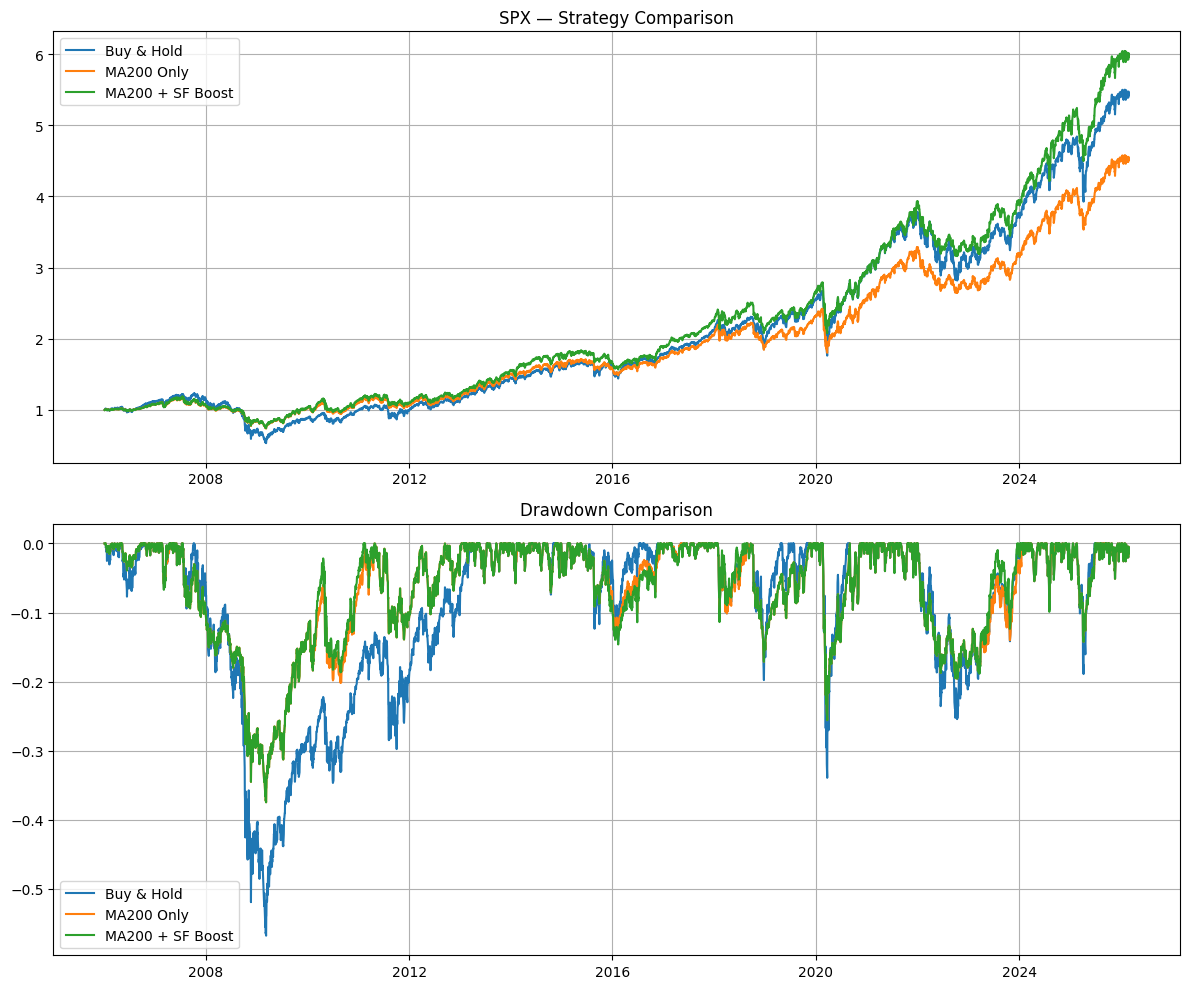

In [35]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

axes[0].plot(df_combined.index, df_combined["equity_bh"], label="Buy & Hold")
axes[0].plot(df_ma200.index, df_ma200["equity_ma200"], label="MA200 Only")
axes[0].plot(df_combined.index, df_combined["equity_combined"], label="MA200 + SF Boost")
axes[0].set_title("SPX — Strategy Comparison")
axes[0].legend()
axes[0].grid(True)

dd_bh = df_combined["equity_bh"] / df_combined["equity_bh"].cummax() - 1
dd_ma200 = df_ma200["equity_ma200"] / df_ma200["equity_ma200"].cummax() - 1
dd_combined = df_combined["equity_combined"] / df_combined["equity_combined"].cummax() - 1

axes[1].plot(df_combined.index, dd_bh, label="Buy & Hold")
axes[1].plot(df_ma200.index, dd_ma200, label="MA200 Only")
axes[1].plot(df_combined.index, dd_combined, label="MA200 + SF Boost")
axes[1].set_title("Drawdown Comparison")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig("strategy_comparison.png", dpi=200)
plt.show()